<a href="https://colab.research.google.com/github/nova888/Data-Science/blob/master/EDADataIPO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Warrant - Price D1.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

First 5 rows of the dataset:


,Ticker Code,Participant Admin,Underwriter(s),Listing Board,Final Price (Rp),Warrant per share ratio,Exercise Price (Warrant) (Rp),Open,High,Low,Close
0,PJHB-W,PO - PILARMAS INVESTINDO SEKURITAS,PO,NaN,330.0,0.5,330.0,51.0,410.0,51.0,410.0
1,DKHH-W,EP - MNC SEKURITAS,EP,Pengembangan,132.0,0.5,155.0,25.0,61.0,15.0,43.0
2,OBAT-W,AD - OSO SEKURITAS INDONESIA,AD,Pengembangan,350.0,0.5,350.0,-,-,-,-
3,BRRC-W,XA - NH KORINDO SEKURITAS INDONESIA,XA,Pengembangan,210.0,0.5,210.0,-,-,-,-
4,NAIK-W,EP - MNC SEKURITAS,EP,Pengembangan,107.0,0.5,135.0,28.0,62.0,23.0,48.0


In [5]:
# Display information about the DataFrame, including data types and non-null values
print('\nDataFrame Info:')
df.info()

# Convert 'Open', 'High', 'Low', 'Close' to numeric, handling non-numeric values
columns_to_convert = ['Open', 'High', 'Low', 'Close']
for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('\nDataFrame Info after converting price columns:')
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Ticker Code                    95 non-null     object 
 1   Participant Admin              95 non-null     object 
 2   Underwriter(s)                 95 non-null     object 
 3   Listing Board                  94 non-null     object 
 4   Final Price (Rp)               94 non-null     float64
 5   Warrant per share ratio        95 non-null     float64
 6   Exercise Price (Warrant) (Rp)  95 non-null     float64
 7   Open                           10 non-null     float64
 8   High                           10 non-null     float64
 9   Low                            10 non-null     float64
 10  Close                          10 non-null     float64
dtypes: float64(7), object(4)
memory usage: 8.3+ KB

DataFrame Info after converting price columns:


In [6]:
# Calculate the correlation between 'Final Price (Rp)' and 'Exercise Price (Warrant) (Rp)'
correlation = df['Final Price (Rp)'].corr(df['Exercise Price (Warrant) (Rp)'])
print(f"Correlation between Final Price (Rp) and Exercise Price (Warrant) (Rp): {correlation:.2f}")

Correlation between Final Price (Rp) and Exercise Price (Warrant) (Rp): 0.96


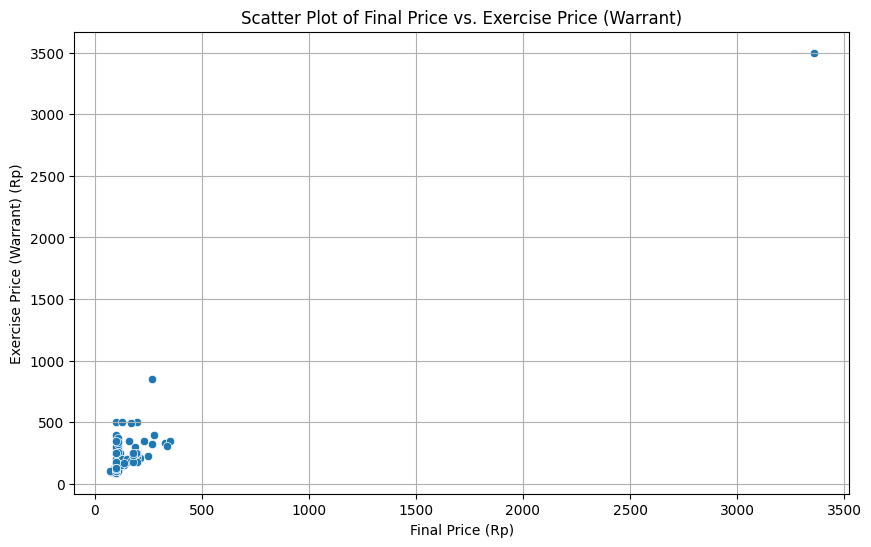

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Final Price (Rp)', y='Exercise Price (Warrant) (Rp)', data=df)
plt.title('Scatter Plot of Final Price vs. Exercise Price (Warrant)')
plt.xlabel('Final Price (Rp)')
plt.ylabel('Exercise Price (Warrant) (Rp)')
plt.grid(True)
plt.show()

In [8]:
# Check unique values and their counts for 'Listing Board'
print("Unique values and counts for 'Listing Board':")
print(df['Listing Board'].value_counts(dropna=False))

Unique values and counts for 'Listing Board':
Listing Board
Pengembangan    65
Akselerasi      24
Utama            5
NaN              1
Name: count, dtype: int64


**Berdasarkan analisis awal:**

1. Hubungan Harga Final dan Harga Pelaksanaan Waran: Terdapat korelasi positif yang sangat kuat (0.96) antara 'Final Price (Rp)' dan 'Exercise Price (Warrant) (Rp)'. Ini berarti kedua harga ini sangat erat kaitannya dan cenderung bergerak sejalan.

2. Keterbatasan Data Harga: Data untuk 'Open', 'High', 'Low', dan 'Close' sangat terbatas (hanya 10 dari 95 entri). Hal ini akan menyulitkan kita untuk menganalisis 'kenaikan harga' secara komprehensif menggunakan kolom-kolom ini untuk sebagian besar IPO.

3. Distribusi 'Listing Board': Sebagian besar IPO dalam dataset ini terdaftar di papan 'Pengembangan', diikuti oleh 'Akselerasi' dan 'Utama'. Informasi ini dapat digunakan untuk menganalisis apakah ada perbedaan kesuksesan antara 'sektor' atau kategori papan pencatatan ini, meskipun 'Listing Board' mungkin bukan representasi 'sektor' yang sepenuhnya akurat tetapi lebih ke segmen pasar.

In [9]:
# Hitung rata-rata 'Final Price (Rp)' berdasarkan 'Listing Board'
average_final_price_by_listing_board = df.groupby('Listing Board')['Final Price (Rp)'].mean().reset_index()

print("Rata-rata Final Price (Rp) berdasarkan Listing Board:")
display(average_final_price_by_listing_board)

Rata-rata Final Price (Rp) berdasarkan Listing Board:


,Listing Board,Final Price (Rp)
0,Akselerasi,111.958333
1,Pengembangan,199.718750
2,Utama,100.000000


In [10]:
# Hitung rata-rata 'Exercise Price (Warrant) (Rp)' berdasarkan 'Listing Board'
average_exercise_price_by_listing_board = df.groupby('Listing Board')['Exercise Price (Warrant) (Rp)'].mean().reset_index()

print("Rata-rata Exercise Price (Warrant) (Rp) berdasarkan Listing Board:")
display(average_exercise_price_by_listing_board)

Rata-rata Exercise Price (Warrant) (Rp) berdasarkan Listing Board:


,Listing Board,Exercise Price (Warrant) (Rp)
0,Akselerasi,158.666667
1,Pengembangan,287.015385
2,Utama,265.000000


Berdasarkan analisis rata-rata 'Exercise Price (Warrant) (Rp)' berdasarkan 'Listing Board':

1. Pengembangan memiliki rata-rata harga pelaksanaan waran tertinggi sekitar rp. 287.02
2. Utama menyusul dengan rata-rata sekitar rp. 265.00
Akselerasi memiliki rata-rata harga pelaksanaan waran terendah sekitar rp. 158.67